In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, get_neighbors_at_radius, VelocityState, image_to_hex_obstacles, hexes_in_between_solid
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution, HStarProblem, BidHStarSearch
from hexplot import plot_hex_grid_2, plot_velocity_profile

import matplotlib.pyplot as plt
import itertools



In [72]:
import math
from typing import Optional, Set, Dict, Iterable, Tuple

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import numpy as np

from hexgrid import HexCoord, hex_disk
from hexplot import axial_to_xy  # uses your existing pointy-top axial->xy helper


def _add_hex(a: HexCoord, b: HexCoord) -> HexCoord:
    return HexCoord(a.q + b.q, a.r + b.r)


def _sub_hex(a: HexCoord, b: HexCoord) -> HexCoord:
    return HexCoord(a.q - b.q, a.r - b.r)


def _hex_midpoint_for_view(cells: Iterable[HexCoord]) -> HexCoord:
    """
    Simple rounded-ish center for plotting window.
    Uses average q/r rounded to nearest int.
    """
    cells = list(cells)
    if not cells:
        return HexCoord(0, 0)

    q = round(sum(c.q for c in cells) / len(cells))
    r = round(sum(c.r for c in cells) / len(cells))
    return HexCoord(q, r)


def _hdist(a: HexCoord, b: HexCoord) -> int:
    dq = abs(a.q - b.q)
    dr = abs(a.r - b.r)
    ds = abs((-a.q - a.r) - (-b.q - b.r))
    return (dq + dr + ds) // 2


def plot_transition_requirements(
    problem,
    from_hex: HexCoord,
    to_hex: HexCoord,
    *,
    ax: Optional[plt.Axes] = None,
    figsize: Tuple[int, int] = (8, 8),
    hex_size: Optional[float] = None,
    radius: Optional[int] = None,
    show_coords: bool = True,
    show_collision_radius_map: bool = True,
    show_nonrequired_obstacles: bool = True,
    annotate: bool = True,
    draw_arrow: bool = True,
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Visualize one transition under the same blocking rules used by HStarProblem.

    Rules mirrored from your implementation:
      - delta must be one of problem.DIRECTIONS_INFO keys
      - required-clear cells = anchor(from_hex) + problem.DIRECTIONS_INFO[delta].blockers
      - a required-clear cell is blocked if it is in:
            problem.grid.obstacles OR problem.collision_radius_map

    Parameters
    ----------
    problem : HStarProblem
    from_hex : HexCoord
        Transition start
    to_hex : HexCoord
        Transition end
    ax : matplotlib Axes, optional
    figsize : tuple
    hex_size : float, optional
        Defaults to problem.grid.hex_size if present, else 1.0
    radius : int, optional
        Plot radius around local center. If None, auto-computed.
    show_coords : bool
    show_collision_radius_map : bool
        Show buffered cells from collision_radius_map
    show_nonrequired_obstacles : bool
        Show all nearby obstacles/buffered cells even if not in required-clear set
    annotate : bool
        Annotate from/to and allowability
    draw_arrow : bool
        Draw arrow from from_hex to to_hex
    title : optional str
    save_path : optional str
    """
    if hex_size is None:
        hex_size = getattr(problem.grid, "hex_size", 1.0)

    delta = _sub_hex(to_hex, from_hex)

    if delta not in problem.DIRECTIONS_INFO:
        available = ", ".join(str(d) for d in problem.DIRECTIONS_INFO.keys())
        raise ValueError(
            f"Transition delta {delta} is not in problem.DIRECTIONS_INFO.\n"
            f"This helper expects a single transition from your n-step basis.\n"
            f"Available direction vectors include: {available}"
        )

    # ---- Apply your exact blocker anchoring rule ----
    step_info = problem.DIRECTIONS_INFO[delta]
    required_clear: Set[HexCoord] = {_add_hex(from_hex, b) for b in step_info.blockers}

    obstacles: Set[HexCoord] = set(problem.grid.obstacles.keys()) if isinstance(problem.grid.obstacles, dict) else set(problem.grid.obstacles)
    collision_buffer: Set[HexCoord] = set(problem.collision_radius_map)

    blocked_required_obstacle = required_clear & obstacles
    blocked_required_buffer = required_clear & collision_buffer
    blocked_required = blocked_required_obstacle | blocked_required_buffer

    # Mirrors collision_clear(coord, blockers):
    # For this transition view, the meaningful swept-clear set is required_clear.
    # If you want to also reflect the explicit anchor check, include from_hex.
    anchor_is_blocked = (from_hex in obstacles) or (from_hex in collision_buffer)
    transition_allowed = (not anchor_is_blocked) and (len(blocked_required) == 0)

    # ---- Build plotting neighborhood ----
    important_cells = {from_hex, to_hex} | required_clear
    if show_nonrequired_obstacles:
        important_cells |= (
            {c for c in obstacles if min(_hdist(c, x) for x in {from_hex, to_hex}) <= 3}
            | {c for c in collision_buffer if min(_hdist(c, x) for x in {from_hex, to_hex}) <= 3}
        )

    center = _hex_midpoint_for_view(important_cells)

    if radius is None:
        radius = max(_hdist(center, c) for c in important_cells) + 2

    cells = list(hex_disk(center, radius))

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        ax.cla()

    # ---- Hex templates ----
    angles = np.linspace(0, 2 * np.pi, 7)[:-1] + np.pi / 6  # pointy-top
    unit_hex = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    hex_template = unit_hex * hex_size

    polys = []
    facecolors = []
    edgecolors = []

    # ---- Colors ----
    COLOR_FREE = "#f7f9fc"
    COLOR_REQUIRED = "#ffd166"          # required-clear cells
    COLOR_REQUIRED_BLOCKED = "#ef476f"  # required-clear but actually blocked
    COLOR_FROM = "#2d6cdf"
    COLOR_TO = "#2eb82e"
    COLOR_OBS = "#444444"
    COLOR_BUFFER = "#b8c4d6"
    EDGE = "#666666"

    for cell in cells:
        x, y = axial_to_xy(cell.q, cell.r, hex_size)
        poly = hex_template + np.array([x, y])
        polys.append(poly)

        fc = COLOR_FREE
        ec = EDGE

        # Background nearby blocking context
        if show_nonrequired_obstacles:
            if cell in obstacles:
                fc = COLOR_OBS
            elif show_collision_radius_map and cell in collision_buffer:
                fc = COLOR_BUFFER

        # Required-clear overlay category
        if cell in required_clear:
            fc = COLOR_REQUIRED
        if cell in blocked_required:
            fc = COLOR_REQUIRED_BLOCKED

        # From / To override everything visually
        if cell == from_hex:
            fc = COLOR_FROM
        elif cell == to_hex:
            fc = COLOR_TO

        facecolors.append(fc)
        edgecolors.append(ec)

        if show_coords:
            txt_color = "white" if fc in {COLOR_FROM, COLOR_TO, COLOR_OBS, COLOR_REQUIRED_BLOCKED} else "#222222"
            ax.text(
                x, y,
                f"({cell.q},{cell.r})",
                ha="center",
                va="center",
                fontsize=8,
                color=txt_color,
                zorder=5,
            )

    collection = PolyCollection(
        polys,
        facecolors=facecolors,
        edgecolors=edgecolors,
        linewidths=0.9,
        zorder=1,
    )
    ax.add_collection(collection)

    # ---- Arrow from start to end ----
    if draw_arrow:
        x1, y1 = axial_to_xy(from_hex.q, from_hex.r, hex_size)
        x2, y2 = axial_to_xy(to_hex.q, to_hex.r, hex_size)
        dx, dy = x2 - x1, y2 - y1
        ax.arrow(
            x1, y1,
            dx * 0.78, dy * 0.78,
            head_width=0.22 * hex_size,
            head_length=0.32 * hex_size,
            length_includes_head=True,
            fc="#111111",
            ec="#111111",
            lw=2.0,
            zorder=6,
        )

    # ---- Annotations ----
    if annotate:
        fx, fy = axial_to_xy(from_hex.q, from_hex.r, hex_size)
        tx, ty = axial_to_xy(to_hex.q, to_hex.r, hex_size)

        ax.text(
            fx, fy + 0.65 * hex_size,
            "FROM",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
            color=COLOR_FROM,
            zorder=7,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
        )

        ax.text(
            tx, ty + 0.65 * hex_size,
            "TO",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
            color=COLOR_TO,
            zorder=7,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
        )
        # subtitle = (
        #     f"delta={delta} | swept cells={len(required_clear)} | "
        #     f"blocked_required={len(blocked_required)} | "
        #     f"allowed={transition_allowed}"
        # )

        # ax.text(
        #     0.5, 1.02,
        #     subtitle,
        #     transform=ax.transAxes,
        #     ha="center",
        #     va="bottom",
        #     fontsize=10,
        #     color="#222222",
        # )

    # ---- Bounds ----
    xs = []
    ys = []
    for c in cells:
        x, y = axial_to_xy(c.q, c.r, hex_size)
        xs.append(x)
        ys.append(y)

    margin = 2.0 * hex_size
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    if title is None:
        title = "H* n-step transition clearance"
    ax.set_title(title)

    # ---- Legend ----
    handles = [
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_FROM, markeredgecolor=EDGE, markersize=10, label="from"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_TO, markeredgecolor=EDGE, markersize=10, label="to"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_REQUIRED, markeredgecolor=EDGE, markersize=10, label="must be clear"),
        #Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_REQUIRED_BLOCKED, markeredgecolor=EDGE, markersize=10, label="required but blocked"),
        #Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_OBS, markeredgecolor=EDGE, markersize=10, label="obstacle"),
        #Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_BUFFER, markeredgecolor=EDGE, markersize=10, label="collision-radius blocked"),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=8)

    if created_fig:
        plt.tight_layout()

    if save_path is not None:
        ax.figure.savefig(save_path, dpi=300, bbox_inches="tight")

    return ax, {
        "from_hex": from_hex,
        "to_hex": to_hex,
        "delta": delta,
        "required_clear": required_clear,
        "blocked_required": blocked_required,
        "blocked_required_obstacle": blocked_required_obstacle,
        "blocked_required_buffer": blocked_required_buffer,
        "anchor_is_blocked": anchor_is_blocked,
        "transition_allowed": transition_allowed,
        "step_distance": step_info.s,
    }

In [73]:
RADIUS = 8
MAP_JPG_SIZE = 1000 # largest dimension in px
a_max = 3
a_min = 2
ay_window_ms = 10

collision_radius = 0

jps_horizon = None
n_step = 3
obs_density = 0.15
hex_size = 1
n_obs = int(obs_density * 3 * RADIUS * (RADIUS + 1))
start = HexCoord(q=-RADIUS + 4, r=RADIUS - 4)
#start = HexCoord(0,0)
goal = HexCoord(q=RADIUS - 4, r=-RADIUS + 4)

obs = build_obstacle_map(
    center = HexCoord(0,0),
    radius = RADIUS,
    types = [("random_n", {"n": n_obs})],
    exclude=[start, goal],
    seed=42
)
obs = set(obs.keys())
from hexgrid import hexes_in_between_solid
from_hex = HexCoord(q = -RADIUS//2 + 5, r = -RADIUS // 2 + 5)
to_hex = HexCoord(q = RADIUS // 2 - 5, r = RADIUS // 2 - 5)
line = hexes_in_between_solid(from_hex, to_hex) 
obs = obs.union(line)


for i in range(5):
    obs = obs - get_neighbors_at_radius(start, i)
    obs = obs - get_neighbors_at_radius(goal, i)

#obs = set()
obs = obs.union(get_neighbors_at_radius(HexCoord(0,0), RADIUS))

In [74]:
hg = HexGrid(hex_size, obs)

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = collision_radius,
    jps_horizon =  jps_horizon,
    ay_window_ms = ay_window_ms,
    n_step = n_step,   
    start_v = VelocityState(0, None),
    goal_v = VelocityState(0, None)
)


hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)

fsolution = hs.search()
fsolution_path = construct_full_solution(fsolution)
benchmarks = hs.get_benchmarks()
print(f'Search time: {benchmarks["search_time"]}s')
print(f'Solution cost: {benchmarks["solution_cost"]}')

Search time: 0.023790597915649414s
Solution cost: inf


Allowed: True
Required-clear cells: {HexCoord(q=1, r=0), HexCoord(q=0, r=-1), HexCoord(q=1, r=-1), HexCoord(q=0, r=0)}
Blocked required cells: set()


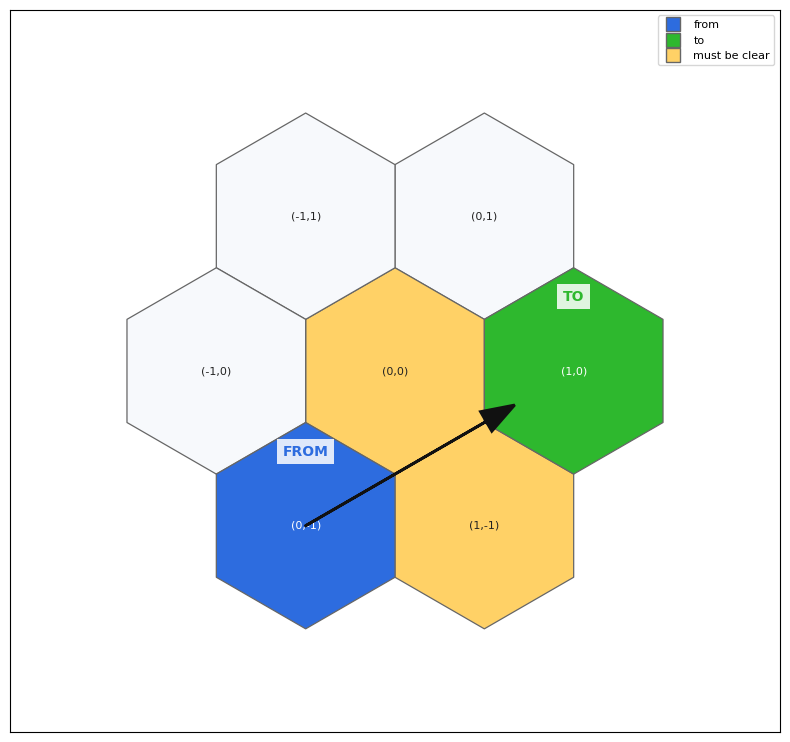

In [75]:
# Example: pick one exact transition from your n-step basis
from_hex = HexCoord(0, -1)
to_hex   = HexCoord(1, 0)   # must be one of problem.DIRECTIONS_INFO keys

ax, info = plot_transition_requirements(
    problem,
    from_hex=from_hex,
    to_hex=to_hex,
    show_coords=True,
    show_collision_radius_map=False,
    show_nonrequired_obstacles=False,
    annotate=True,
    radius = 1,
    title="",
)

print("Allowed:", info["transition_allowed"])
print("Required-clear cells:", info["required_clear"])
print("Blocked required cells:", info["blocked_required"])

In [64]:
from hexgrid import euclid_center_distance
euclid_center_distance(HexCoord(0,1), HexCoord(1,0))

1.7320508075688772

In [65]:
import math
from typing import Optional, Iterable, Tuple, Dict, Set, List

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
import numpy as np

from hexgrid import HexCoord, VelocityState, circular_slice, value_at_index, hex_disk
from hexplot import axial_to_xy


def _add_hex(a: HexCoord, b: HexCoord) -> HexCoord:
    return HexCoord(a.q + b.q, a.r + b.r)


def _sub_hex(a: HexCoord, b: HexCoord) -> HexCoord:
    return HexCoord(a.q - b.q, a.r - b.r)


def _hdist(a: HexCoord, b: HexCoord) -> int:
    dq = abs(a.q - b.q)
    dr = abs(a.r - b.r)
    ds = abs((-a.q - a.r) - (-b.q - b.r))
    return (dq + dr + ds) // 2


def _avg_center(cells: Iterable[HexCoord]) -> HexCoord:
    cells = list(cells)
    if not cells:
        return HexCoord(0, 0)
    q = round(sum(c.q for c in cells) / len(cells))
    r = round(sum(c.r for c in cells) / len(cells))
    return HexCoord(q, r)


def get_transition_summary_for_origin(
    problem,
    origin: HexCoord,
    *,
    heading_idx: Optional[int] = None,
) -> List[Dict]:
    """
    Compute all one-shot basis transitions from `origin` using problem.DIRECTIONS,
    and classify them by:
      - whether they are in the heading cone
      - whether the transition is allowed under anchored blocker rules

    This mirrors:
      - problem.DIRECTIONS / problem.DIRECTIONS_INFO
      - problem.candidate_dir_indices(...) cone logic
      - problem.collision_clear(...)
    """
    obstacles = set(problem.grid.obstacles.keys()) if isinstance(problem.grid.obstacles, dict) else set(problem.grid.obstacles)
    collision_buffer = set(problem.collision_radius_map)

    idx_range = list(range(len(problem.DIRECTIONS)))

    if heading_idx is None:
        cone_indices = set(idx_range)
    else:
        offset = value_at_index(problem.n_step)
        cone_indices = set(circular_slice(idx_range, heading_idx - offset, heading_idx + offset + 1))

    rows = []

    for idx, d in enumerate(problem.DIRECTIONS):
        dest = _add_hex(origin, d)

        step_info = problem.DIRECTIONS_INFO[d]
        required_clear = {_add_hex(origin, b) for b in step_info.blockers}

        blocked_required_obstacle = required_clear & obstacles
        blocked_required_buffer = required_clear & collision_buffer
        blocked_required = blocked_required_obstacle | blocked_required_buffer

        # Mirror collision_clear(dest, blockers=required_clear_or_anchored_blockers)
        dest_blocked = dest in obstacles or dest in collision_buffer
        allowed = (not dest_blocked) and (len(blocked_required) == 0)

        rows.append({
            "dir_idx": idx,
            "dir_vec": d,
            "dest": dest,
            "in_cone": idx in cone_indices,
            "allowed": allowed,
            "required_clear": required_clear,
            "blocked_required": blocked_required,
            "blocked_required_obstacle": blocked_required_obstacle,
            "blocked_required_buffer": blocked_required_buffer,
            "step_distance": step_info.s,
        })

    return rows


def plot_available_transitions_with_cone(
    problem,
    origin: HexCoord,
    *,
    heading_idx: Optional[int] = None,
    ax: Optional[plt.Axes] = None,
    figsize: Tuple[int, int] = (10, 10),
    hex_size: Optional[float] = None,
    radius: Optional[int] = None,
    show_coords: bool = True,
    show_dir_labels: bool = True,
    show_arrows: bool = True,
    show_collision_radius_map: bool = True,
    show_nearby_obstacles: bool = True,
    annotate_heading: bool = True,
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Plot all basis transitions from one origin and highlight which are inside the
    +/- 60° candidate cone used by your heading-aware action generation.

    Color meaning for transition ENDPOINTS:
      - dark green : allowed + in cone
      - light green: allowed + outside cone
      - orange     : blocked + in cone
      - pink/red   : blocked + outside cone

    Background:
      - dark gray  : obstacle
      - light gray : collision-radius-blocked cell
      - blue       : origin
    """
    if hex_size is None:
        hex_size = getattr(problem.grid, "hex_size", 1.0)

    rows = get_transition_summary_for_origin(problem, origin, heading_idx=heading_idx)

    obstacles = set(problem.grid.obstacles.keys()) if isinstance(problem.grid.obstacles, dict) else set(problem.grid.obstacles)
    collision_buffer = set(problem.collision_radius_map)

    transition_endpoints = {row["dest"] for row in rows}

    important_cells = {origin} | transition_endpoints

    if show_nearby_obstacles:
        important_cells |= {
            c for c in obstacles
            if min(_hdist(c, x) for x in ({origin} | transition_endpoints)) <= max(problem.n_step + 1, 3)
        }
        if show_collision_radius_map:
            important_cells |= {
                c for c in collision_buffer
                if min(_hdist(c, x) for x in ({origin} | transition_endpoints)) <= max(problem.n_step + 1, 3)
            }

    center = _avg_center(important_cells)

    if radius is None:
        radius = max(_hdist(center, c) for c in important_cells) + 2

    cells = list(hex_disk(center, radius))

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        ax.cla()

    # ---------- Hex geometry ----------
    angles = np.linspace(0, 2 * np.pi, 7)[:-1] + np.pi / 6  # pointy-top
    unit_hex = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    hex_template = unit_hex * hex_size

    polys = []
    facecolors = []
    edgecolors = []

    # ---------- Colors ----------
    COLOR_FREE = "#f7f9fc"
    COLOR_ORIGIN = "#2d6cdf"
    COLOR_OBS = "#444444"
    COLOR_BUFFER = "#cfd8e3"

    COLOR_ALLOWED_IN_CONE = "#228b22"
    COLOR_ALLOWED_OUTSIDE = "#a7dca6"
    COLOR_BLOCKED_IN_CONE = "#ff9f1c"
    COLOR_BLOCKED_OUTSIDE = "#f4a6b8"

    EDGE = "#666666"

    endpoint_color_map: Dict[HexCoord, str] = {}
    endpoint_row_map: Dict[HexCoord, Dict] = {}

    for row in rows:
        endpoint_row_map[row["dest"]] = row
        if row["allowed"] and row["in_cone"]:
            endpoint_color_map[row["dest"]] = COLOR_ALLOWED_IN_CONE
        elif row["allowed"] and not row["in_cone"]:
            endpoint_color_map[row["dest"]] = COLOR_ALLOWED_OUTSIDE
        elif not row["allowed"] and row["in_cone"]:
            endpoint_color_map[row["dest"]] = COLOR_BLOCKED_IN_CONE
        else:
            endpoint_color_map[row["dest"]] = COLOR_BLOCKED_OUTSIDE

    # ---------- Draw cells ----------
    xs, ys = [], []

    for cell in cells:
        x, y = axial_to_xy(cell.q, cell.r, hex_size)
        xs.append(x)
        ys.append(y)

        poly = hex_template + np.array([x, y])
        polys.append(poly)

        fc = COLOR_FREE
        ec = EDGE

        if show_nearby_obstacles:
            if cell in obstacles:
                fc = COLOR_OBS
            elif show_collision_radius_map and cell in collision_buffer:
                fc = COLOR_BUFFER

        if cell in endpoint_color_map:
            fc = endpoint_color_map[cell]

        if cell == origin:
            fc = COLOR_ORIGIN

        facecolors.append(fc)
        edgecolors.append(ec)

    coll = PolyCollection(
        polys,
        facecolors=facecolors,
        edgecolors=edgecolors,
        linewidths=0.9,
        zorder=1,
    )
    ax.add_collection(coll)

    # ---------- Draw arrows ----------
    if show_arrows:
        x0, y0 = axial_to_xy(origin.q, origin.r, hex_size)

        for row in rows:
            dest = row["dest"]
            x1, y1 = axial_to_xy(dest.q, dest.r, hex_size)

            dx = x1 - x0
            dy = y1 - y0

            color = endpoint_color_map[dest]
            lw = 2.8 if row["in_cone"] else 1.4
            alpha = 1.0 if row["in_cone"] else 0.65

            ax.arrow(
                x0, y0,
                dx * 0.83, dy * 0.83,
                head_width=0.16 * hex_size,
                head_length=0.24 * hex_size,
                length_includes_head=True,
                fc="#000000",
                ec="#000000",
                lw=lw,
                alpha=alpha,
                zorder=4,
            )

    # ---------- Labels ----------
    for cell in cells:
        x, y = axial_to_xy(cell.q, cell.r, hex_size)

        if show_coords:
            txt = f"({cell.q},{cell.r})"
            txt_color = "#222222"
            if cell == origin or cell in obstacles:
                txt_color = "white"
            if cell in endpoint_color_map and endpoint_color_map[cell] in {COLOR_ALLOWED_IN_CONE, COLOR_BLOCKED_IN_CONE}:
                txt_color = "white"

            ax.text(
                x, y - 0.10 * hex_size,
                txt,
                ha="center",
                va="center",
                fontsize=7,
                color=txt_color,
                zorder=5,
            )

        if show_dir_labels and cell in endpoint_row_map:
            row = endpoint_row_map[cell]
            label = f"{row['dir_idx']}"
            ax.text(
                x, y + 0.28 * hex_size,
                label,
                ha="center",
                va="center",
                fontsize=9,
                weight="bold",
                color="black",
                zorder=6,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
            )

    if annotate_heading:
        ox, oy = axial_to_xy(origin.q, origin.r, hex_size)
        if heading_idx is None:
            heading_text = "heading=None (all directions treated as in-cone)"
        else:
            try:
                hvec = problem.DIRECTIONS[heading_idx]
                heading_text = f"heading_idx={heading_idx}, heading_vec={hvec}"
            except Exception:
                heading_text = f"heading_idx={heading_idx}"

        ax.text(
            ox,
            oy + 0.85 * hex_size,
            heading_text,
            ha="center",
            va="bottom",
            fontsize=10,
            color=COLOR_ORIGIN,
            zorder=7,
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none"),
        )

    # ---------- Summary ----------
    allowed_in = sum(1 for r in rows if r["allowed"] and r["in_cone"])
    blocked_in = sum(1 for r in rows if (not r["allowed"]) and r["in_cone"])
    allowed_out = sum(1 for r in rows if r["allowed"] and (not r["in_cone"]))
    blocked_out = sum(1 for r in rows if (not r["allowed"]) and (not r["in_cone"]))

    # summary = (
    #     f"allowed+in_cone={allowed_in} | blocked+in_cone={blocked_in} | "
    #     f"allowed+outside={allowed_out} | blocked+outside={blocked_out}"
    # )

    # ax.text(
    #     0.5, 1.015,
    #     summary,
    #     transform=ax.transAxes,
    #     ha="center",
    #     va="bottom",
    #     fontsize=10,
    #     color="#222222",
    # )

    # ---------- Bounds ----------
    margin = 2.0 * hex_size
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    if title is None:
        title = "Available n-step transitions and ±60° heading cone"
    #ax.set_title(title)

    # ---------- Legend ----------
    handles = [
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_ORIGIN, markeredgecolor=EDGE, markersize=10, label="origin"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_ALLOWED_IN_CONE, markeredgecolor=EDGE, markersize=10, label="allowed + in cone"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_ALLOWED_OUTSIDE, markeredgecolor=EDGE, markersize=10, label="allowed + outside cone"),
        #Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_BLOCKED_IN_CONE, markeredgecolor=EDGE, markersize=10, label="blocked + in cone"),
        #Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_BLOCKED_OUTSIDE, markeredgecolor=EDGE, markersize=10, label="blocked + outside cone"),
        #Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_OBS, markeredgecolor=EDGE, markersize=10, label="obstacle"),
        #Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_BUFFER, markeredgecolor=EDGE, markersize=10, label="collision-radius blocked"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8, frameon=True)

    if created_fig:
        plt.tight_layout()

    if save_path is not None:
        ax.figure.savefig(save_path, dpi=300, bbox_inches="tight")

    return ax, rows

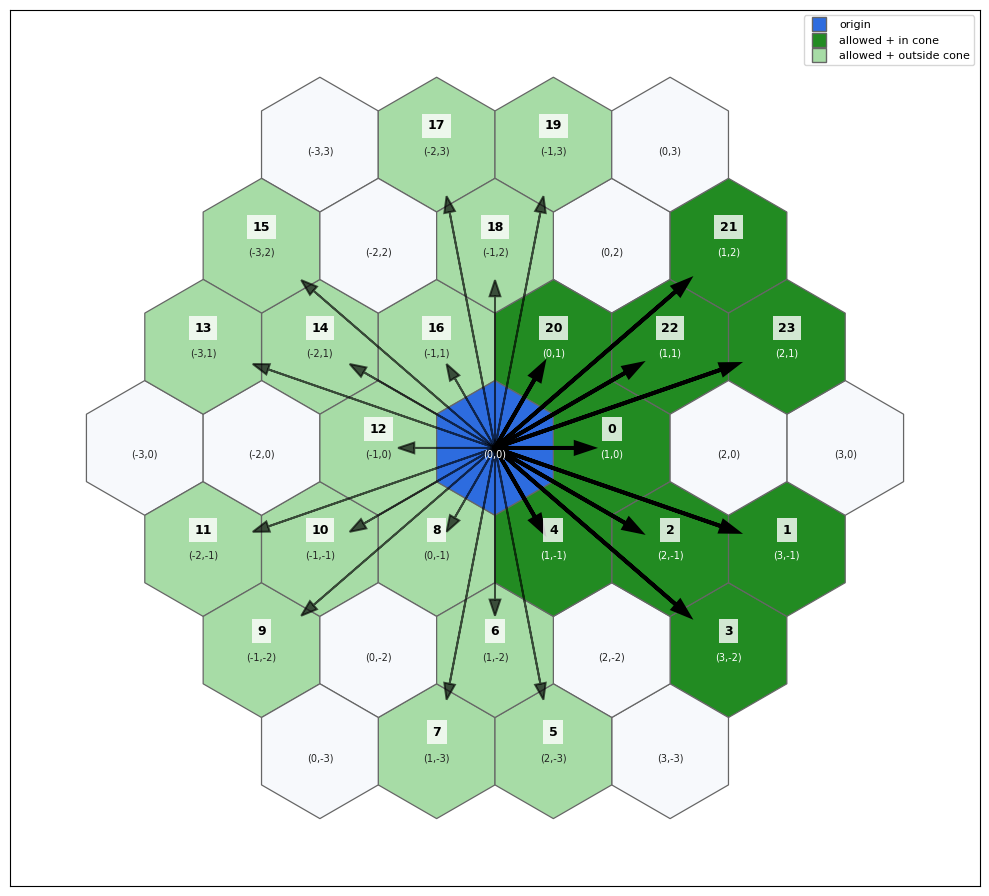

In [69]:
origin = HexCoord(0, 0)

ax, rows = plot_available_transitions_with_cone(
    problem,
    origin,
    heading_idx=0,   # choose your current agent heading index
    show_coords=True,
    show_dir_labels=True,
    show_arrows=True,
    annotate_heading=False,
    radius=3,
    title="n-step transitions from one state",
)

In [67]:
import math
from typing import Optional, Iterable, Tuple, Dict, Set, List

import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
import numpy as np

from hexgrid import HexCoord, hex_disk, circular_slice, value_at_index
from hexplot import axial_to_xy


def _add_hex(a: HexCoord, b: HexCoord) -> HexCoord:
    return HexCoord(a.q + b.q, a.r + b.r)


def _hdist(a: HexCoord, b: HexCoord) -> int:
    dq = abs(a.q - b.q)
    dr = abs(a.r - b.r)
    ds = abs((-a.q - a.r) - (-b.q - b.r))
    return (dq + dr + ds) // 2


def _avg_center(cells: Iterable[HexCoord]) -> HexCoord:
    cells = list(cells)
    if not cells:
        return HexCoord(0, 0)
    q = round(sum(c.q for c in cells) / len(cells))
    r = round(sum(c.r for c in cells) / len(cells))
    return HexCoord(q, r)


def _ordered_cells_on_ray(
    origin: HexCoord,
    direction: HexCoord,
    reachable_set: Set[HexCoord],
    *,
    max_steps: int = 10000,
) -> List[HexCoord]:
    """
    Convert the reachable set returned by get_available_hexes_in_dir(...) into
    an ordered list along the ray:
        origin + 1*direction, origin + 2*direction, ...
    """
    out: List[HexCoord] = []
    cur = origin
    for _ in range(max_steps):
        cur = _add_hex(cur, direction)
        if cur not in reachable_set:
            break
        out.append(cur)
    return out


def compute_turn_seeking_expansions(
    problem,
    origin: HexCoord,
    *,
    heading_idx: Optional[int] = None,
):
    """
    Compute the same heading-filtered ray expansions used by actions(...),
    but return a rich summary for plotting/debugging.

    Returns a list of dicts, one per direction in problem.DIRECTIONS.
    """
    idx_range = list(range(len(problem.DIRECTIONS)))

    if heading_idx is None:
        cone_indices = set(idx_range)
    else:
        offset = value_at_index(problem.n_step)
        cone_indices = set(
            circular_slice(idx_range, heading_idx - offset, heading_idx + offset + 1)
        )

    rows = []

    for di, d in enumerate(problem.DIRECTIONS):
        reachable_set = problem.get_available_hexes_in_dir(
            origin,
            d,
            include_start=False,
            ray_range=problem.jps_horizon,
        )

        ordered_cells = _ordered_cells_on_ray(origin, d, set(reachable_set))
        step_size = float(problem.DIRECTIONS_INFO[d].s)

        cells_info = []
        for k, cell in enumerate(ordered_cells, start=1):
            cells_info.append({
                "cell": cell,
                "k": k,
                "segment_distance": k * step_size,
            })

        rows.append({
            "dir_idx": di,
            "dir_vec": d,
            "in_cone": di in cone_indices,
            "step_size": step_size,
            "reachable_cells": ordered_cells,
            "reachable_info": cells_info,
        })

    return rows


def plot_turn_seeking_expansions(
    problem,
    origin: HexCoord,
    *,
    heading_idx: Optional[int] = None,
    ax: Optional[plt.Axes] = None,
    figsize: Tuple[int, int] = (11, 11),
    hex_size: Optional[float] = None,
    radius: Optional[int] = None,
    show_coords: bool = True,
    show_step_labels: bool = True,
    label_mode: str = "k_and_distance",   # "k", "distance", "k_and_distance", "dir_only"
    show_direction_labels: bool = True,
    show_arrows: bool = True,
    show_collision_radius_map: bool = True,
    show_nearby_obstacles: bool = True,
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Plot all straight-line turn-seeking ray expansions from `origin`.

    Meaning of plotted ray cells:
      each highlighted cell is a valid child destination returned by
      get_available_hexes_in_dir(...) for one direction vector.

    If heading_idx is provided, rays inside the same heading cone used by
    candidate_dir_indices(...) are emphasized.
    """
    if hex_size is None:
        hex_size = getattr(problem.grid, "hex_size", 1.0)

    obstacles = (
        set(problem.grid.obstacles.keys())
        if isinstance(problem.grid.obstacles, dict)
        else set(problem.grid.obstacles)
    )
    collision_buffer = set(problem.collision_radius_map)

    rows = compute_turn_seeking_expansions(problem, origin, heading_idx=heading_idx)

    # Collect plotted cells
    ray_cells: Set[HexCoord] = set()
    for row in rows:
        ray_cells.update(row["reachable_cells"])

    important_cells = {origin} | ray_cells

    if show_nearby_obstacles:
        important_cells |= {
            c for c in obstacles
            if min(_hdist(c, x) for x in ({origin} | ray_cells)) <= max(problem.n_step + 2, 4)
        }
        if show_collision_radius_map:
            important_cells |= {
                c for c in collision_buffer
                if min(_hdist(c, x) for x in ({origin} | ray_cells)) <= max(problem.n_step + 2, 4)
            }

    center = _avg_center(important_cells)

    if radius is None:
        radius = max(_hdist(center, c) for c in important_cells) + 2

    cells = list(hex_disk(center, radius))

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        ax.cla()

    # ---------- pointy-top hex geometry ----------
    angles = np.linspace(0, 2 * np.pi, 7)[:-1] + np.pi / 6
    unit_hex = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    hex_template = unit_hex * hex_size

    # ---------- colors ----------
    COLOR_FREE = "#f7f9fc"
    COLOR_ORIGIN = "#2d6cdf"
    COLOR_OBS = "#444444"
    COLOR_BUFFER = "#cfd8e3"

    # ray cells
    COLOR_IN_CONE = "#228b22"
    COLOR_OUT_CONE = "#a7dca6"

    EDGE = "#666666"

    # quick lookup from cell -> first owning row (for labels/colors)
    cell_to_rows: Dict[HexCoord, List[dict]] = {}
    for row in rows:
        for info in row["reachable_info"]:
            cell_to_rows.setdefault(info["cell"], []).append({
                "dir_idx": row["dir_idx"],
                "dir_vec": row["dir_vec"],
                "in_cone": row["in_cone"],
                "k": info["k"],
                "segment_distance": info["segment_distance"],
            })

    polys = []
    facecolors = []
    edgecolors = []
    xs, ys = [], []

    for cell in cells:
        x, y = axial_to_xy(cell.q, cell.r, hex_size)
        xs.append(x)
        ys.append(y)

        poly = hex_template + np.array([x, y])
        polys.append(poly)

        fc = COLOR_FREE
        ec = EDGE

        # background obstacle context
        if show_nearby_obstacles:
            if cell in obstacles:
                fc = COLOR_OBS
            elif show_collision_radius_map and cell in collision_buffer:
                fc = COLOR_BUFFER

        # ray-expansion cells
        if cell in cell_to_rows:
            # if any incoming ray is in-cone, make it the stronger color
            if any(r["in_cone"] for r in cell_to_rows[cell]):
                fc = COLOR_IN_CONE
            else:
                fc = COLOR_OUT_CONE

        # origin overrides everything
        if cell == origin:
            fc = COLOR_ORIGIN

        facecolors.append(fc)
        edgecolors.append(ec)

    collection = PolyCollection(
        polys,
        facecolors=facecolors,
        edgecolors=edgecolors,
        linewidths=0.9,
        zorder=1,
    )
    ax.add_collection(collection)

    # ---------- draw rays ----------
    if show_arrows:
        x0, y0 = axial_to_xy(origin.q, origin.r, hex_size)

        for row in rows:
            ray = row["reachable_cells"]
            if not ray:
                continue

            color = COLOR_IN_CONE if row["in_cone"] else COLOR_OUT_CONE
            lw = 2.8 if row["in_cone"] else 1.3
            alpha = 1.0 if row["in_cone"] else 0.65

            prev = origin
            for cell in ray:
                x1, y1 = axial_to_xy(prev.q, prev.r, hex_size)
                x2, y2 = axial_to_xy(cell.q, cell.r, hex_size)
                dx, dy = x2 - x1, y2 - y1

                ax.arrow(
                    x1, y1,
                    dx * 0.82, dy * 0.82,
                    head_width=0.14 * hex_size,
                    head_length=0.20 * hex_size,
                    length_includes_head=True,
                    fc=color,
                    ec=color,
                    lw=lw,
                    alpha=alpha,
                    zorder=4,
                )
                prev = cell

    # ---------- labels ----------
    for cell in cells:
        x, y = axial_to_xy(cell.q, cell.r, hex_size)

        if show_coords:
            txt_color = "#222222"
            if cell == origin or cell in obstacles:
                txt_color = "white"
            elif cell in cell_to_rows and any(r["in_cone"] for r in cell_to_rows[cell]):
                txt_color = "white"

            ax.text(
                x,
                y - 0.10 * hex_size,
                f"({cell.q},{cell.r})",
                ha="center",
                va="center",
                fontsize=7,
                color=txt_color,
                zorder=5,
            )

        if cell in cell_to_rows:
            # choose one label if multiple rays coincide; prefer in-cone
            infos = sorted(cell_to_rows[cell], key=lambda r: (not r["in_cone"], r["k"]))
            info = infos[0]

            if show_step_labels:
                if label_mode == "k":
                    label = f"k={info['k']}"
                elif label_mode == "distance":
                    label = f"s={info['segment_distance']:.2f}"
                elif label_mode == "dir_only":
                    label = f"d{info['dir_idx']}"
                else:  # "k_and_distance"
                    label = f"k={info['k']}\ns={info['segment_distance']:.2f}"

                ax.text(
                    x,
                    y + 0.22 * hex_size,
                    label,
                    ha="center",
                    va="center",
                    fontsize=8,
                    weight="bold",
                    color="black",
                    zorder=6,
                    bbox=dict(facecolor="white", alpha=0.82, edgecolor="none"),
                )

    # direction labels at ray ends
    if show_direction_labels:
        for row in rows:
            ray = row["reachable_cells"]
            if not ray:
                continue
            end = ray[-1]
            x, y = axial_to_xy(end.q, end.r, hex_size)
            label = f"dir={row['dir_idx']}\nvec={row['dir_vec']}"
            ax.text(
                x,
                y + 0.72 * hex_size,
                label,
                ha="center",
                va="bottom",
                fontsize=8,
                color=COLOR_IN_CONE if row["in_cone"] else "#3b6b3b",
                zorder=7,
                bbox=dict(facecolor="white", alpha=0.88, edgecolor="none"),
            )

    # origin annotation
    ox, oy = axial_to_xy(origin.q, origin.r, hex_size)
    if heading_idx is None:
        heading_text = "heading=None (all rays treated as in-cone)"
    else:
        try:
            heading_vec = problem.DIRECTIONS[heading_idx]
            heading_text = f"heading_idx={heading_idx}\nheading_vec={heading_vec}"
        except Exception:
            heading_text = f"heading_idx={heading_idx}"

    ax.text(
        ox,
        oy + 0.92 * hex_size,
        heading_text,
        ha="center",
        va="bottom",
        fontsize=10,
        color=COLOR_ORIGIN,
        zorder=8,
        bbox=dict(facecolor="white", alpha=0.92, edgecolor="none"),
    )

    # summary
    rays_in_cone = sum(1 for r in rows if r["in_cone"])
    rays_out_cone = sum(1 for r in rows if not r["in_cone"])
    cells_in_cone = sum(len(r["reachable_cells"]) for r in rows if r["in_cone"])
    cells_out_cone = sum(len(r["reachable_cells"]) for r in rows if not r["in_cone"])

    summary = (
        f"in-cone rays={rays_in_cone}, out-of-cone rays={rays_out_cone} | "
        f"in-cone child cells={cells_in_cone}, out-of-cone child cells={cells_out_cone}"
    )

    ax.text(
        0.5, 1.015,
        summary,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        color="#222222",
    )

    # bounds
    margin = 2.0 * hex_size
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    if title is None:
        title = "Turn-seeking ray expansions (children encode distance-to-last-turn)"
    ax.set_title(title)

    handles = [
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_ORIGIN, markeredgecolor=EDGE, markersize=10, label="origin"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_IN_CONE, markeredgecolor=EDGE, markersize=10, label="reachable child (in cone)"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_OUT_CONE, markeredgecolor=EDGE, markersize=10, label="reachable child (outside cone)"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_OBS, markeredgecolor=EDGE, markersize=10, label="obstacle"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COLOR_BUFFER, markeredgecolor=EDGE, markersize=10, label="collision-radius blocked"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8, frameon=True)

    if created_fig:
        plt.tight_layout()

    if save_path is not None:
        ax.figure.savefig(save_path, dpi=300, bbox_inches="tight")

    return ax, rows

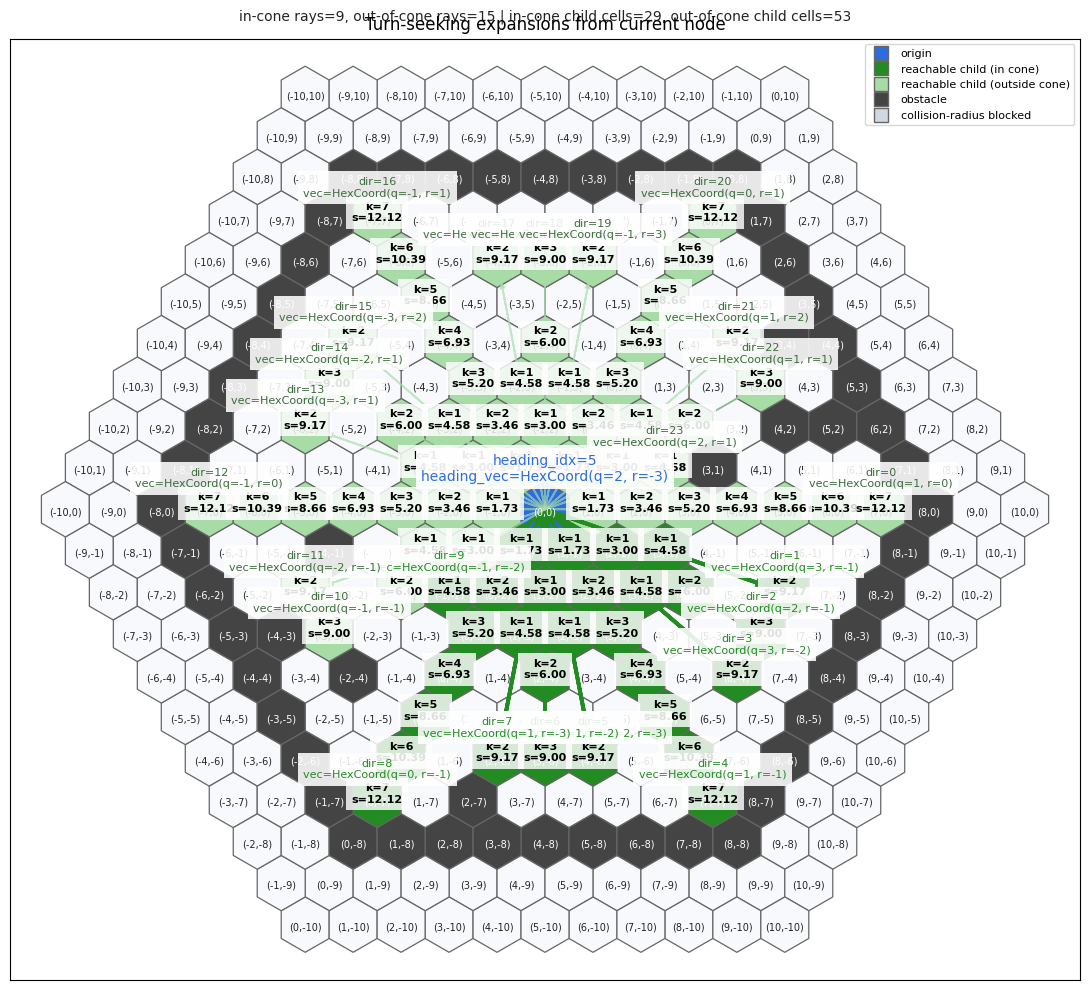

In [68]:
origin = HexCoord(0, 0)
heading_idx = 5   # whatever your node.velocity.direction is

ax, rows = plot_turn_seeking_expansions(
    problem,
    origin,
    heading_idx=heading_idx,
    show_coords=True,
    show_step_labels=True,
    label_mode="k_and_distance",
    show_direction_labels=True,
    show_arrows=True,
    title="Turn-seeking expansions from current node",
)